In [1]:
import os
import re
import sys
import pickle
import pandas as pd
import spacy
from tqdm import tqdm

import nltk
from nltk.tokenize.api import TokenizerI
from nltk.tokenize import word_tokenize
from typing import List, Dict
from nltk.tokenize import TreebankWordTokenizer

Load previously calculated lexicons and annotations

In [2]:
path_annotations = "../data/annotations"
path_lexicons = "../data/lexicons"
path_predictions = "../data/predictions"

os.makedirs(path_predictions, exist_ok=True)

Load the training data

In [3]:
df_train = pickle.load(open(os.path.join(path_annotations, "df_train.pkl"), "rb"))
print(f"Loaded {len(df_train)} annotations")

Loaded 9319 annotations


In [4]:
df_train

,doc_id,line_id,annotation_id,start,end,label,text
0,19026587,19026587_2,19026587_2_ent0,0,1,NEG,no
1,19026587,19026587_2,19026587_2_ent1,1,4,NSCO,habitos toxicos.
2,19026587,19026587_4,19026587_4_ent2,38,39,NSCO,cistoscopia
3,19026587,19026587_4,19026587_4_ent3,41,42,NEG,negativa
4,19026587,19026587_4,19026587_4_ent4,42,45,NSCO,para lesiones malignas
...,...,...,...,...,...,...,...
9314,20339886,20339886_29,20339886_29_ent40,25,26,NSCO,streptotest
9315,20339886,20339886_29,20339886_29_ent41,49,50,NSCO,urocultivo
9316,20339886,20339886_30,20339886_30_ent42,102,103,NSCO,hemocultivo
9317,20339886,20339886_30,20339886_30_ent43,126,127,NSCO,foco


In [5]:
from nltk.tokenize import word_tokenize

In [6]:
def preprocess_text(text):
    if not text or pd.isna(text):
        return ""
        
    text = text.lower().strip()
    
    return text.strip()


def find_cues(text, cue_lexicon, verbose=False):
    """
    Find all instances of cues in the text
    
    Parameters:
        text list[str]: Tokenized text to search for cues
        cue_lexicon (DataFrame): Lexicon containing cues
        
    Returns:
        list: List of dictionaries with cue information
    """
    if not text:
        return []

    cues = []
    
    lemmas = set(cue_lexicon["term"].tolist())

    # Find each cue term in the text
    for term in lemmas:
        indices = [i for i, x in enumerate(text) if x == term]
        if verbose:
            print(f"Term '{term}' found at indices: {indices}")
        for index in indices:
            start = index
            end = index + 1

            if verbose:
                print(f"Found cue '{term}' at index {index}")
            cues.append({
                "start": start,
                "end": end,
                "text": " ".join(text[start:end]),
                "token": text[start],
                "term": term
            })
    
    # Sort cues by position in text
    cues = sorted(cues, key=lambda x: x["start"])
    return cues

**Document Processing Function**

The `process_document()` function generates predictions for a single document:

For each line of text in the document:
- Preprocess the text (lowercase, extract relevant section)
- Find negation cues by matching terms from the lexicon
- For each negation cue:
   - Create a NEG prediction
   - Determine the scope affected by this negation
   - Create an NSCO prediction for the scope
- Find uncertainty cues by matching terms from the lexicon
- For each uncertainty cue:
   - Create a UNC prediction
   - Determine the scope affected by this uncertainty
   - Create a USCO prediction for the scope

This approach creates predictions based only on text pattern matching, without using existing labels

In [7]:
def is_punctuation(token):
    return token in {".", ",", ";", ":"}

def find_scope(cue, processed_text, all_cues):
    scope = {}

    # Special case: if the cue is preceded by a colon, the scope goes backwards
    if cue["start"] >= 1 and processed_text[cue["start"] - 1] == ":":
        # Look for the beginning of the phrase before the colon
        start = 0
        for i in range(cue["start"] - 2, -1, -1):  # Start before the colon and move backward
            if processed_text[i] in {".", ";", "!", "?", ","}:
                start = i + 1
                break
        scope["start"] = start
        scope["end"] = cue["start"] - 1  # Exclude the colon itself
    
    else:
        # Regular case: scope goes forward
        scope["start"] = cue["end"]

        # Tokens or cue positions that can stop the scope early
        stop_tokens = {"pero", "aunque", ".", "y", "-", ";", '-no', 'procediments', '(', ')'}
        stop_positions = set()
        for other_cue in all_cues:
            if other_cue["start"] > cue["end"]:
                stop_positions.add(other_cue["start"])

        # Look ahead to find where the scope should end
        for i in range(scope["start"], len(processed_text)):
            if is_punctuation(processed_text[i]):
                scope["end"] = i + 1  # Include the punctuation
                break
            if processed_text[i] in stop_tokens or i in stop_positions:
                scope["end"] = i
                break
        
        # If no explicit end was found, default to the end of the text
        if "end" not in scope:
            scope["end"] = len(processed_text)

        # If the first token in the scope is punctuation or a stop token, shift the scope backwards
        if scope["start"] < len(processed_text) and processed_text[scope["start"]] in stop_tokens:
            sentence_start = 0
            for i in range(cue["start"] - 1, -1, -1):
                if processed_text[i] in {".", "!", "?", ",", ";"}:
                    sentence_start = i + 1
                    break
            scope["start"] = sentence_start
            scope["end"] = cue["end"] - 1

    # Extract scope text
    scope["text"] = processed_text[scope["start"]:scope["end"]]

    # Return only if it's a valid scope
    return scope if scope["start"] < scope["end"] else None

In [41]:
def process_document(doc_id, document_texts, tokenizer: TokenizerI, negation_lexicon: pd.DataFrame, uncertainty_lexicon: pd.DataFrame):
    """
    Process a document to detect negation and uncertainty
    
    Parameters:
        doc_id (str): Document ID
        document_texts (dict): Dictionary mapping line numbers to text
        tokenizer (TokenizerI): Tokenizer to use for processing text
        negation_lexicon (DataFrame): Lexicon containing negation cues
        uncertainty_lexicon (DataFrame): Lexicon containing uncertainty cues
        
    Returns:
        list: List of prediction dictionaries
    """

    predictions = []
    for line_num, text in document_texts.items():
        if not text:
            continue
            
        text_lowercase = preprocess_text(text)

        if not hasattr(tokenizer, "tokenize") or not callable(tokenizer.tokenize):
            raise TypeError("Tokenizer must have a callable 'tokenize' method.")
        
        tokenizer_func = tokenizer()

        if not text_lowercase:
            processed_text = []
        else:
            processed_text = tokenizer_func.tokenize(text_lowercase)

        # Find uncertainty cues
        unc_cues = find_cues(processed_text, uncertainty_lexicon)
        # Find negation cues
        neg_cues = find_cues(processed_text, negation_lexicon)

        all_cues = unc_cues + neg_cues
        
        for neg_cue in neg_cues:
            predictions.append({
                "doc_id": doc_id,
                "line_id": f"{doc_id}_{line_num}",
                "start": neg_cue["start"],
                "end": neg_cue["end"],
                "label": "NEG",
                "text": processed_text[neg_cue["start"]:neg_cue["end"]]
            }) # Add NEG prediction

            cues_for_scope = ["no", "sin", "ni", "negativo:", 
                              "negativa", "negativos", "negativas", "niega", "rechaza", "ningun", "ninguna", "cap", "mai",
                              "tampoc", "absencia", "rebutja", "inexistent", "negatiu", "negatius", "negatives"]
            if neg_cue["term"] in cues_for_scope:
                scope = find_scope(neg_cue, processed_text, all_cues)
            
                if scope: # Add NSCO prediction if scope is non-empty
                    predictions.append({
                        "doc_id": doc_id,
                        "line_id": f"{doc_id}_{line_num}",
                        "start": scope["start"],
                        "end": scope["end"],
                        "label": "NSCO",
                        "text": scope["text"],
                        "cue": neg_cue["text"],
                    })

        
        # Process each uncertainty cue
        for cue_idx, unc_cue in enumerate(unc_cues):
            # Add UNC prediction
            predictions.append({
                "doc_id": doc_id,
                "line_id": f"{doc_id}_{line_num}",
                "start": unc_cue["start"],
                "end": unc_cue["end"],
                "label": "UNC",
                "text": processed_text[unc_cue["start"]:unc_cue["end"]]
            })

            cues_for_scope = ["descartar", "compatible con", "puede", "compatible", "sugestivo", "aparentemente", "posible", 
                              "probable", "podria", "probablemente", "sospecha", "possible", "probablement", 
                              "aparentment", "sospita", "se sospecha"]
            if unc_cue["term"] in cues_for_scope:
                scope = find_scope(unc_cue, processed_text, all_cues)
                
                if scope: # Add USCO prediction if scope is non-empty
                    predictions.append({
                        "doc_id": doc_id,
                        "line_id": f"{doc_id}_{line_num}",
                        "start": scope["start"],
                        "end": scope["end"],
                        "label": "USCO",
                        "text": scope["text"],
                        "cue": unc_cue["text"],
                    })

    return predictions

**Text Extraction Process**

The document text extraction code works as follows:

- Create an empty dictionary `doc_texts` to store all document texts
- For each unique document ID in our dataframe:
   - Filter the dataframe to get only rows for this document
   - Create a dictionary `texts` to store lines for this document
   - For each unique line number in this document:
     - Filter to get only annotations for this line
     - Check each annotation in this line
     - This gives us the most complete text for this line
   - Store the line texts dictionary in our main document dictionary

This extraction preserves the document and line structure while giving us just the text content to work with

In [42]:
with open(os.path.join(path_lexicons, "negation/negation.csv")) as f:
    negation_lexicon = pd.read_csv(f)

with open(os.path.join(path_lexicons, "uncertainty/uncertainty.csv")) as f:
    uncertainty_lexicon = pd.read_csv(f)

In [43]:
from nltk.tokenize import TreebankWordTokenizer

documents_directory = "../data/documents"

# loop over the documents
all_predictions = []

re_doc = re.compile(r"(\d+)\.txt$")

for document_name in tqdm(os.listdir(documents_directory)):
    match_obj = re_doc.match(document_name)
    if match_obj:
        doc_id = match_obj.group(1)

        # Load the document
        with open(os.path.join(documents_directory, f"{doc_id}.txt"), "r") as file:
            document_texts = {i: line.strip() for i, line in enumerate(file.readlines())}
        
        pred = process_document(doc_id, document_texts, TreebankWordTokenizer, negation_lexicon, uncertainty_lexicon)
        all_predictions.extend(pred)

100%|██████████| 248/248 [00:03<00:00, 76.25it/s] 


In [44]:
df_train_pred = pd.DataFrame(all_predictions)
print(f"Generated {len(df_train_pred)} predictions")

print("Prediction distribution:")
print(df_train_pred["label"].value_counts())

# Save predictions to file
output_file = os.path.join(path_predictions, "df_train_predictions.pkl")
pickle.dump(df_train_pred, open(output_file, "wb"))
print(f"Saved predictions to {output_file}")

Generated 9069 predictions
Prediction distribution:
label
NEG     4503
NSCO    3682
UNC      563
USCO     321
Name: count, dtype: int64
Saved predictions to ../data/predictions/df_train_predictions.pkl


## Accuracy Calculation

First we calculate using the "interval", as it is done with the annotations in the training and test data.

In [45]:
import sys
sys.path.append("..")

from utils.metrics import calculate_entity_accuracy

All labels:

In [46]:
accuracy = calculate_entity_accuracy(df_train, df_train_pred, verbose=1)
print(f"Accuracy: {100*accuracy:.2f}%")

True Positives (TP): 5459
False Positives (FP): 3610
False Negatives (FN): 3786
Accuracy: 42.47%


Just NEG and UNC:

In [47]:
df_train_filtered = df_train[(df_train["label"] == "NEG") | (df_train["label"] == "UNC")]
df_train_pred_filtered = df_train_pred[(df_train_pred["label"] == "NEG") | (df_train_pred["label"] == "UNC")]

In [48]:
accuracy_filtered = calculate_entity_accuracy(df_train_filtered, df_train_pred_filtered, verbose=1)
print(f"Filtered accuracy: {100*accuracy_filtered:.2f}%")

True Positives (TP): 4216
False Positives (FP): 850
False Negatives (FN): 509
Filtered accuracy: 75.62%


### Accuracy per token

With this metric we expect to get a higher value. We consider that this is a more resonable metric:
For example, in some scopes the final period `.` is included in it, in other no. Since we define our scopes including it, in the cases were is not included we would get a false positive, despite having all of the other words predicted correctly.

We use a function that passes an annotation dataframe (either the groud thruth) to a per-token annotations. Note that this would increase the dataframe size significantly.


In [49]:
import pandas as pd

def expand_annotations(df):
    """
    Expands annotations in a pandas DataFrame to per-token annotations.

    Args:
        df (pd.DataFrame): Input DataFrame with 'start' and 'end' columns.

    Returns:
        pd.DataFrame: DataFrame with expanded annotations.
    """

    new_rows = []
    for index, row in df.iterrows():
        start = row['start']
        end = row['end']
        
        # If the interval is just one token, keep it as is
        if end - start == 1:
            new_rows.append(row.to_dict())
        else:
            # Expand the interval into individual tokens
            for i in range(start, end):
                new_row = row.copy()
                new_row['start'] = i
                new_row['end'] = i + 1
                new_rows.append(new_row.to_dict())
    
    return pd.DataFrame(new_rows)

In [50]:
from utils.metrics import plot_full_confusion_matrix

In [51]:
expanded_train = expand_annotations(df_train)
expanded_pred = expand_annotations(df_train_pred)

accuracy_expanded = calculate_entity_accuracy(expanded_train, expanded_pred, verbose=1)
print(f"Expanded accuracy: {100*accuracy_expanded:.2f}%")

True Positives (TP): 16675
False Positives (FP): 7605
False Negatives (FN): 4448
Expanded accuracy: 58.04%


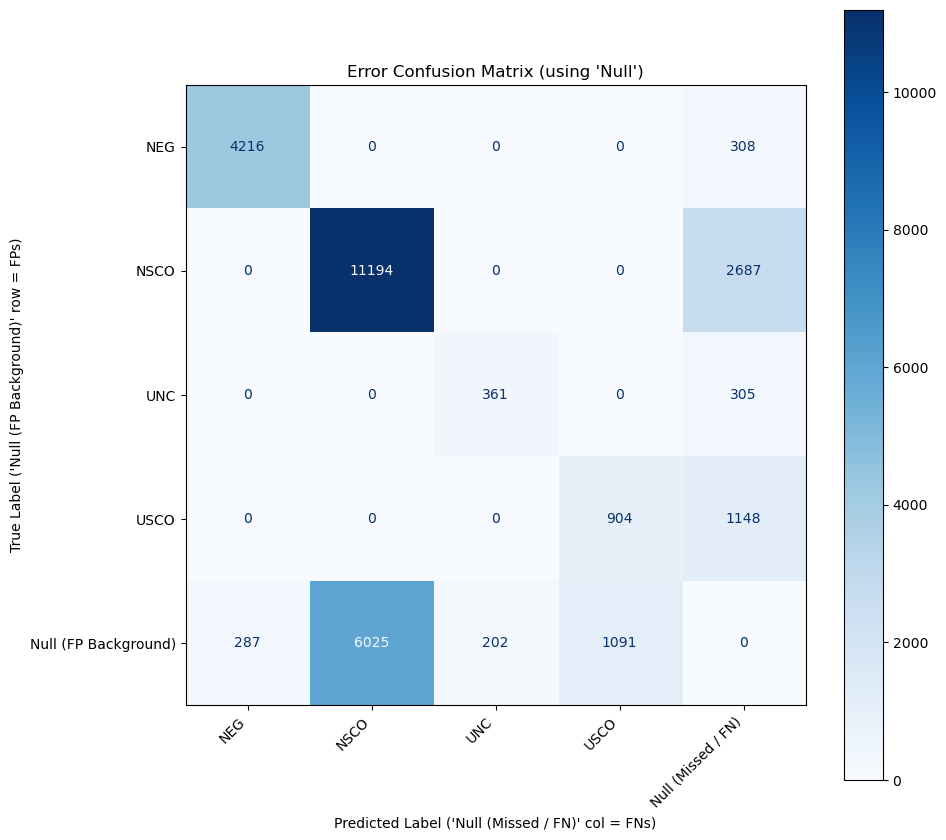

In [52]:
ax1 = plot_full_confusion_matrix(expanded_train, expanded_pred, figsize=(10, 10))

In [20]:
from utils.metrics import get_specific_errors

In [21]:
nsco_fp = get_specific_errors(expanded_train, expanded_pred, target_label='NSCO', error_type='FP')
nsco_fp

Found 6137 examples of FP for label 'NSCO' in Predictions (df_pred).


,doc_id,line_id,start,end,label,text,cue
8,18806985,18806985_1,9,10,NSCO,"[alergias, medicamentosas, calendario, vacunal...",sin
9,18806985,18806985_1,10,11,NSCO,"[alergias, medicamentosas, calendario, vacunal...",sin
10,18806985,18806985_1,11,12,NSCO,"[alergias, medicamentosas, calendario, vacunal...",sin
11,18806985,18806985_1,12,13,NSCO,"[alergias, medicamentosas, calendario, vacunal...",sin
15,18806985,18806985_1,16,17,NSCO,"[requirio, ingreso, .]",no
...,...,...,...,...,...,...,...
24441,18977663,18977663_28,41,42,NSCO,"[,]",negativos
24443,18977663,18977663_29,0,1,NSCO,"[mmr-deficiency, :, mlh1, y, msh6]",negativos
24444,18977663,18977663_29,1,2,NSCO,"[mmr-deficiency, :, mlh1, y, msh6]",negativos
24445,18977663,18977663_29,2,3,NSCO,"[mmr-deficiency, :, mlh1, y, msh6]",negativos


In [22]:
usco_fp = get_specific_errors(expanded_train, expanded_pred, target_label='USCO', error_type='FP')
usco_fp

Found 1097 examples of FP for label 'USCO' in Predictions (df_pred).


,doc_id,line_id,start,end,label,text,cue
60,18806985,18806985_27,4,5,USCO,"[espaciarse, progresivamente, con, mejoria, su...",puede
61,18806985,18806985_27,5,6,USCO,"[espaciarse, progresivamente, con, mejoria, su...",puede
62,18806985,18806985_27,6,7,USCO,"[espaciarse, progresivamente, con, mejoria, su...",puede
63,18806985,18806985_27,7,8,USCO,"[espaciarse, progresivamente, con, mejoria, su...",puede
64,18806985,18806985_27,8,9,USCO,"[espaciarse, progresivamente, con, mejoria, su...",puede
...,...,...,...,...,...,...,...
23807,20261883,20261883_1,21,22,USCO,"[de, bacteriemia, por, infeccion, urinaria, .]",sospecha
24428,18977663,18977663_21,17,18,USCO,"[infiltracion, del, mismo, .]",descartar
24429,18977663,18977663_21,18,19,USCO,"[infiltracion, del, mismo, .]",descartar
24430,18977663,18977663_21,19,20,USCO,"[infiltracion, del, mismo, .]",descartar


## Test Data Evaluation

Load test data:

In [27]:
df_test = pickle.load(open(os.path.join(path_annotations, "df_test.pkl"), "rb"))

In [25]:
test_documents_directory = "../data/documents_test"

test_predictions = []

re_doc = re.compile(r"(\d+)\.txt$")

for document_name in tqdm(os.listdir(test_documents_directory)):
    match_obj = re_doc.match(document_name)
    if match_obj:
        doc_id = match_obj.group(1)

        with open(os.path.join(test_documents_directory, f"{doc_id}.txt"), "r") as file:
            document_texts = {i: line.strip() for i, line in enumerate(file.readlines())}
        
        pred = process_document(doc_id, document_texts, TreebankWordTokenizer, negation_lexicon, uncertainty_lexicon)
        test_predictions.extend(pred)

100%|██████████| 63/63 [00:00<00:00, 159.62it/s]


In [26]:
df_test_pred = pd.DataFrame(test_predictions)
print(f"Generated {len(df_test_pred)} test predictions")
print("Test prediction distribution:")
print(df_test_pred["label"].value_counts())


Generated 2340 test predictions
Test prediction distribution:
label
NEG     1163
NSCO     933
UNC      149
USCO      95
Name: count, dtype: int64


In [28]:
df_test_filtered = df_test[(df_test["label"] == "NEG") | (df_test["label"] == "UNC")]
df_test_pred_filtered = df_test_pred[(df_test_pred["label"] == "NEG") | (df_test_pred["label"] == "UNC")]

accuracy_test_filtered = calculate_entity_accuracy(df_test_filtered, df_test_pred_filtered, verbose=1)
print(f"Filtered test accuracy: {100*accuracy_test_filtered:.2f}%")

True Positives (TP): 1101
False Positives (FP): 211
False Negatives (FN): 152
Filtered test accuracy: 75.20%


Per token evaluation:

In [29]:
expanded_test = expand_annotations(df_test)
expanded_test_pred = expand_annotations(df_test_pred)

accuracy_test_expanded = calculate_entity_accuracy(expanded_test, expanded_test_pred, verbose=1)
print(f"Expanded test accuracy: {100*accuracy_test_expanded:.2f}%")

True Positives (TP): 4268
False Positives (FP): 1774
False Negatives (FN): 1225
Expanded test accuracy: 58.73%
